## Assessment

In [20]:
#  Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb


In [22]:
#  Data 
df = pd.read_excel('../data/abt.xlsx')

cols_to_drop = []
X = df.drop(columns=['price_per_square_meter']).drop(columns=cols_to_drop)
y = df['price_per_square_meter']

# Detect OHE dummy columns by their prefix (they are int dtype, not object)
# Matches the same logic used in 04_model.ipynb
categorical_cols = [c for c in X.columns if c.startswith('material_') or c.startswith('district_')]
numerical_cols   = X.columns.difference(categorical_cols).tolist()

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# CV setup 
scoring = {
    'r2':   'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_summary(cv_results):
    df_cv = pd.DataFrame({
        'r2':   cv_results['test_r2'],
        'rmse': -cv_results['test_rmse'],
        'mae':  -cv_results['test_mae'],
        'mape': -cv_results['test_mape'],
    }).agg(['mean', 'std'])
    df_cv[['rmse', 'mae']] = df_cv[['rmse', 'mae']].round(1)
    df_cv[['r2']] = df_cv[['r2']].round(4)
    df_cv[['mape']] = df_cv[['mape']].round(4)
    return df_cv

# Load pipeline definitions from 04_model
# Pipelines are saved by 04_model.ipynb — run that notebook first to refresh them.
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
baseline       = joblib.load(MODELS_DIR / "baseline_pipeline.pkl")
dt_pipeline    = joblib.load(MODELS_DIR / "dt_pipeline.pkl")
rf_pipeline    = joblib.load(MODELS_DIR / "rf_pipeline.pkl")
xgb_pipeline   = joblib.load(MODELS_DIR / "xgb_pipeline.pkl")
lasso_pipeline = joblib.load(MODELS_DIR / "lasso_pipeline.pkl")
print("Pipelines loaded from models/")
print(f"categorical={categorical_cols}")
print(f"numerical={numerical_cols}")

# Cross-validation 
# n_jobs=2 avoids WinError 1450 (insufficient system resources with n_jobs=-1)
N_JOBS = 2
print("Running 10-fold CV for all models ")
baseline_cv = cross_validate(baseline,       X_train, y_train, cv=cv, scoring=scoring, n_jobs=N_JOBS)
dt_cv       = cross_validate(dt_pipeline,    X_train, y_train, cv=cv, scoring=scoring, n_jobs=N_JOBS)
rf_cv       = cross_validate(rf_pipeline,    X_train, y_train, cv=cv, scoring=scoring, return_estimator=True, n_jobs=N_JOBS)
xgb_cv      = cross_validate(xgb_pipeline,   X_train, y_train, cv=cv, scoring=scoring, return_estimator=True, n_jobs=N_JOBS)
lasso_cv    = cross_validate(lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=N_JOBS)


Pipelines loaded from models/
categorical=['material_group_brick', 'material_group_modern', 'material_group_other', 'material_group_prefab', 'district_group_Bielany_Bemowo', 'district_group_Ochota_Mokotów', 'district_group_Rembertów_Wawer_Białołęka', 'district_group_Targówek_Ursus', 'district_group_Ursynów_Praga Północ', 'district_group_Wilanów_Wola', 'district_group_Włochy_Praga Południe', 'district_group_Żoliborz_Śródmieście']
numerical=['building_age', 'dist_to_center', 'dist_to_metro', 'floor', 'market', 'river_side', 'rooms', 'surface']
Running 10-fold CV for all models 


In [23]:
# 10-fold CV comparison (mean across folds)
cv_comparison = pd.DataFrame({
    'Baseline':      cv_summary(baseline_cv).loc['mean'],
    'Decision Tree': cv_summary(dt_cv).loc['mean'],
    'Random Forest': cv_summary(rf_cv).loc['mean'],
    'XGBoost':       cv_summary(xgb_cv).loc['mean'],
    'Lasso':         cv_summary(lasso_cv).loc['mean'],
}).T
cv_comparison


,r2,rmse,mae,mape
Baseline,-0.0010,4378.7,3385.0,0.1939
Decision Tree,0.5512,2927.1,1781.0,0.0988
Random Forest,0.7573,2153.9,1344.0,0.0750
XGBoost,0.7514,2180.8,1429.0,0.0798
Lasso,0.4791,3159.0,2316.9,0.1298


# Final Test on Holdout

In [24]:
# Fit best models on full train set; evaluate on sealed holdout
holdout_results = {}
for name, pipeline in [('Random Forest', rf_pipeline), ('XGBoost', xgb_pipeline)]:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_holdout)
    holdout_results[name] = {
        'r2':   round(r2_score(y_holdout, y_pred), 4),
        'rmse': round(np.sqrt(mean_squared_error(y_holdout, y_pred)), 1),
        'mae':  round(mean_absolute_error(y_holdout, y_pred), 1),
        'mape': round(mean_absolute_percentage_error(y_holdout, y_pred), 4),
    }

pd.DataFrame(holdout_results).T


,r2,rmse,mae,mape
Random Forest,0.7669,2136.3,1371.4,0.0773
XGBoost,0.7709,2117.9,1429.6,0.0809


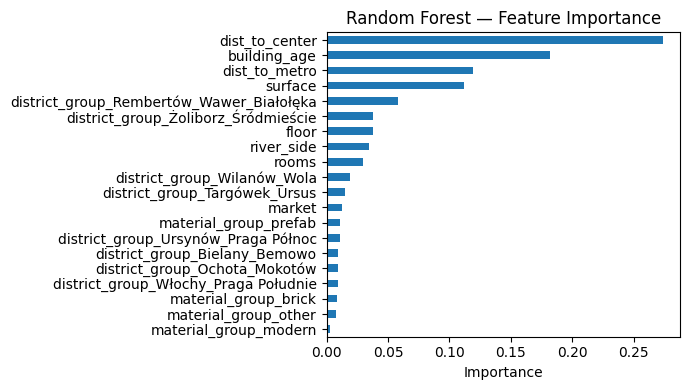

In [25]:
# Feature importance from best CV fold (RF)
best_rf = rf_cv['estimator'][np.argmax(rf_cv['test_r2'])]
feat_names = categorical_cols + numerical_cols
rf_imp = (
    pd.Series(best_rf.named_steps['model'].feature_importances_, index=feat_names)
    .sort_values()
)

rf_imp.plot(kind='barh', figsize=(7, 4))
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()


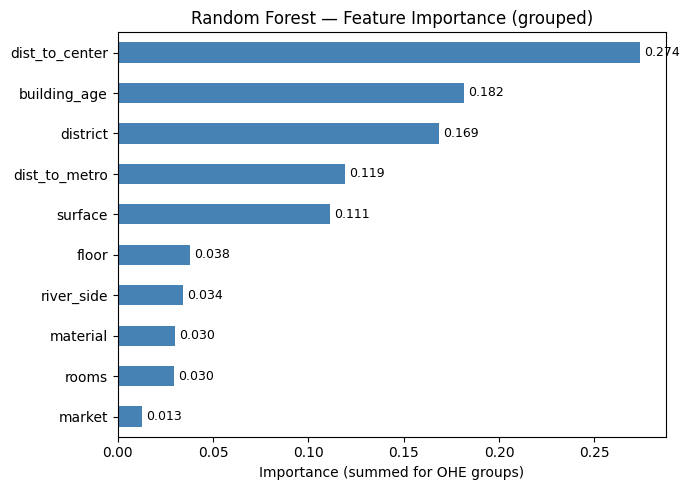

In [29]:
# Feature importance grouped by category prefix
grouped_imp = {}

# Sum all district_* and material_* dummies into one entry each
for prefix in ['district_', 'material_']:
    grouped_imp[prefix.rstrip('_')] = rf_imp[rf_imp.index.str.startswith(prefix)].sum()

# Add numerical features individually
for col in numerical_cols:
    if col in rf_imp.index:
        grouped_imp[col] = rf_imp[col]

grouped_series = pd.Series(grouped_imp).sort_values()

ax = grouped_series.plot(kind='barh', figsize=(7, 5), color='steelblue')
ax.set_xlabel('Importance (summed for OHE groups)')
ax.set_title('Random Forest — Feature Importance (grouped)')
for bar, val in zip(ax.patches, grouped_series):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


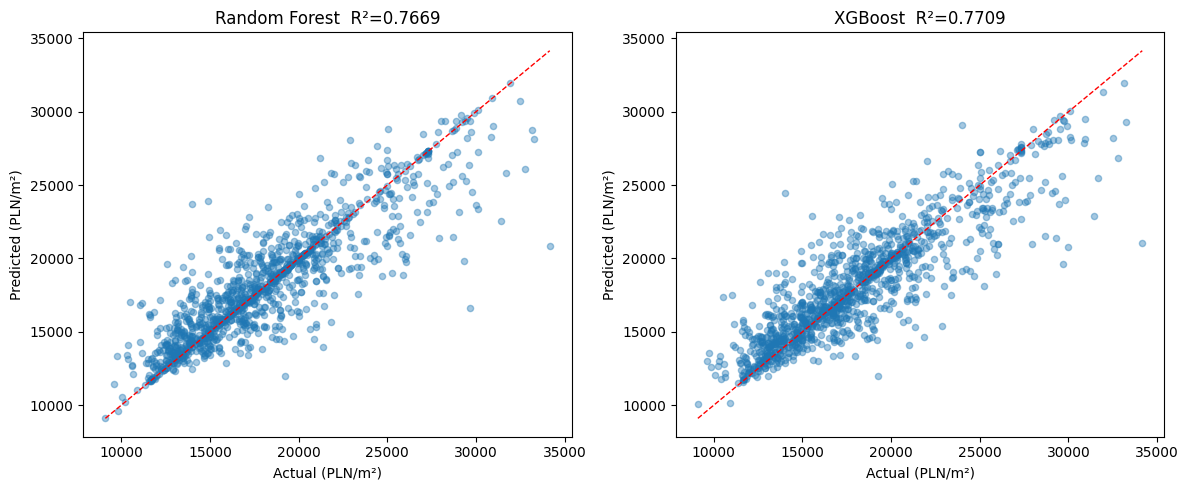

In [26]:
# Predicted vs actual — holdout set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pipeline) in zip(axes, [('Random Forest', rf_pipeline), ('XGBoost', xgb_pipeline)]):
    y_pred = pipeline.predict(X_holdout)
    lims = [min(y_holdout.min(), y_pred.min()), max(y_holdout.max(), y_pred.max())]
    ax.scatter(y_holdout, y_pred, alpha=0.4, s=20)
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual (PLN/m²)')
    ax.set_ylabel('Predicted (PLN/m²)')
    ax.set_title(f'{name}  R²={r2_score(y_holdout, y_pred):.4f}')
plt.tight_layout()
plt.show()


In [27]:
import joblib
import pickle
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Save best Random Forest pipeline (fitted on full X_train above)
joblib.dump(rf_pipeline, MODELS_DIR / "price_model.pkl")
print("Model saved to models/price_model.pkl")

# Save the full ordered feature column list matching the pipeline's ColumnTransformer.
# The ColumnTransformer processes categorical_cols first, then numerical_cols —
# so feature_cols must use the same order; the app constructs its input from this list.
feature_cols = categorical_cols + numerical_cols
with open(MODELS_DIR / "feature_columns.pkl", "wb") as fh:
    pickle.dump(feature_cols, fh)
print(f"Feature columns saved ({len(feature_cols)} total): {feature_cols}")


Model saved to models/price_model.pkl
Feature columns saved (20 total): ['material_group_brick', 'material_group_modern', 'material_group_other', 'material_group_prefab', 'district_group_Bielany_Bemowo', 'district_group_Ochota_Mokotów', 'district_group_Rembertów_Wawer_Białołęka', 'district_group_Targówek_Ursus', 'district_group_Ursynów_Praga Północ', 'district_group_Wilanów_Wola', 'district_group_Włochy_Praga Południe', 'district_group_Żoliborz_Śródmieście', 'building_age', 'dist_to_center', 'dist_to_metro', 'floor', 'market', 'river_side', 'rooms', 'surface']


In [28]:
app_code = r'''import pickle
import joblib
from pathlib import Path

import streamlit as st
import pandas as pd

# -- Page config ---------------------------------------------------------------
st.set_page_config(
    page_title="Warsaw Apartment Price Estimator",
    page_icon="\U0001f3e0",
    layout="centered",
)

# -- Model + artifact loading --------------------------------------------------
MODELS_DIR = Path(__file__).resolve().parent.parent / "models"


@st.cache_resource
def get_model():
    return joblib.load(MODELS_DIR / "price_model.pkl")


@st.cache_resource
def get_feature_columns():
    with open(MODELS_DIR / "feature_columns.pkl", "rb") as fh:
        return pickle.load(fh)


@st.cache_resource
def get_district_tier_map():
    """dict: district_name -> tier (int 0-6, data-driven from training set)."""
    with open(MODELS_DIR / "district_tier_map.pkl", "rb") as fh:
        return pickle.load(fh)


# -- Derive available material groups from saved feature columns ---------------
@st.cache_resource
def get_material_groups():
    feature_cols = get_feature_columns()
    return sorted([c.replace("material_group_", "") for c in feature_cols if c.startswith("material_group_")])


# -- River-side lookup (1 = east/right bank, 0 = west/left bank) ---------------
# Matches the encoding in 03_modify.ipynb
EAST_BANK = {
    "Bia\u0142o\u0142\u0119ka",
    "Praga Po\u0142udnie",
    "Praga P\u00f3\u0142noc",
    "Rembertow",
    "Targ\u00f3wek",
    "Wawer",
    "Weso\u0142a",
}


def river_side_for(district_name: str) -> int:
    return 1 if district_name in EAST_BANK else 0


# -- UI ------------------------------------------------------------------------
st.title("\U0001f3e0 Warsaw Apartment Price Estimator")
st.caption(
    "Predict the price per m\u00b2 (PLN) using a Random Forest model "
    "trained on Warsaw real-estate listings."
)
st.divider()

district_tier_map = get_district_tier_map()
material_groups   = get_material_groups()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Property details")
    rooms = st.number_input("Number of rooms", min_value=1, max_value=10, value=3, step=1)
    surface = st.number_input("Surface area (m\u00b2)", min_value=10.0, max_value=500.0, value=60.0, step=1.0)
    floor = st.number_input("Floor number", min_value=-1, max_value=30, value=2, step=1)
    construction_year = st.number_input(
        "Year of construction", min_value=1900, max_value=2030, value=2000, step=1
    )
    market = st.selectbox("Market type", options=[(0, "Primary"), (1, "Secondary")], format_func=lambda x: x[1])[0]
    material_group = st.selectbox("Building material", options=material_groups)

with col2:
    st.subheader("Location")
    district_name = st.selectbox("District", options=sorted(district_tier_map.keys()))
    dist_to_metro = st.number_input(
        "Distance to nearest metro station (km)", min_value=0.0, max_value=30.0, value=1.0, step=0.1, format="%.2f"
    )
    dist_to_center = st.number_input(
        "Distance to city centre (km)", min_value=0.0, max_value=50.0, value=5.0, step=0.1, format="%.2f"
    )

st.divider()

# -- Derived features ----------------------------------------------------------
current_year = pd.Timestamp.now().year
building_age     = current_year - construction_year
district_tier    = int(district_tier_map[district_name])
river_side_code  = river_side_for(district_name)
bank_label = "East bank (right side of Vistula)" if river_side_code == 1 else "West bank (left side of Vistula)"

with st.expander("Derived values used by the model", expanded=False):
    st.markdown(
        f"""
        | Feature | Value |
        |---|---|
        | Building age | **{building_age}** years |
        | District price tier | **{district_tier}** / 6 (0 = cheapest area, 6 = most expensive) |
        | River side | **{river_side_code}** ({bank_label}) |
        """
    )

# -- Prediction ----------------------------------------------------------------
if st.button("Estimate price per m\u00b2", type="primary", use_container_width=True):
    model = get_model()
    feature_columns = get_feature_columns()

    # Build input row: start with zeros for all features
    input_dict = {col: 0 for col in feature_columns}

    # Set OHE material group dummy
    mat_col = f"material_group_{material_group}"
    if mat_col in input_dict:
        input_dict[mat_col] = 1

    # Set numeric features
    input_dict["building_age"]   = building_age
    input_dict["dist_to_center"] = dist_to_center
    input_dict["dist_to_metro"]  = dist_to_metro
    input_dict["floor"]          = floor
    input_dict["market"]         = market
    input_dict["river_side"]     = river_side_code
    input_dict["rooms"]          = rooms
    input_dict["surface"]        = surface
    input_dict["district_tier"]  = district_tier

    input_df = pd.DataFrame([input_dict])[feature_columns]

    try:
        price_per_m2 = model.predict(input_df)[0]
        st.success(f"### Estimated price: **{price_per_m2:,.0f} PLN / m\u00b2**")
        if surface > 0:
            total = price_per_m2 * surface
            st.info(f"Total estimated value for {surface:.0f} m\u00b2: **{total:,.0f} PLN**")
    except Exception as e:
        st.error(f"Prediction error: {e}")
'''

app_path = Path("../app/estimate_app.py")
app_path.write_text(app_code, encoding="utf-8")
print(f"Written {len(app_code)} chars to {app_path.resolve()}")


Written 5242 chars to C:\Users\klimanska.n\warsaw_real_estate_market\app\estimate_app.py
